In [1]:
import pandas as pd

df = pd.read_csv('train_road_safety.csv')

df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46649 entries, 0 to 46648
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   status                              44293 non-null  object 
 1   collision_index                     46649 non-null  object 
 2   collision_year                      44261 non-null  float64
 3   collision_reference                 44343 non-null  object 
 4   vehicle_reference                   46649 non-null  float64
 5   casualty_reference                  46649 non-null  float64
 6   casualty_class                      46649 non-null  int64  
 7   sex_of_casualty                     44319 non-null  float64
 8   age_of_casualty                     46649 non-null  int64  
 9   age_band_of_casualty                46649 non-null  int64  
 10  pedestrian_location                 46649 non-null  float64
 11  pedestrian_movement                 46649

,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,enhanced_casualty_severity,casualty_severity
count,44261.0,46649.000000,46649.000000,46649.000000,44319.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,44314.000000,46649.000000,44292.000000,46649.000000,46649.000000,46649.000000
mean,2024.0,1.455616,1.353898,1.485520,1.366637,37.102982,6.326502,0.795227,0.657442,0.196574,0.058072,0.031548,9.314112,0.993227,4.132307,1.582220,2.882741
std,0.0,1.444068,1.267332,0.732898,0.577406,19.826586,2.493991,2.196648,2.047634,0.647400,0.465305,0.286917,15.842578,0.979042,3.286280,2.273239,0.362108
min,2024.0,0.462251,0.595506,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,2024.0,1.000000,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,-1.000000,3.000000
50%,2024.0,1.000000,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,4.000000,3.000000,3.000000
75%,2024.0,2.000000,1.000000,2.000000,2.000000,51.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,7.000000,3.000000,3.000000
max,2024.0,203.000000,202.000000,3.000000,9.000000,120.000000,11.000000,10.334651,9.000000,9.000000,9.000000,2.000000,98.000000,3.000000,10.000000,7.000000,3.000000


In [2]:
#Cek missing values

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()


status                                2356
collision_year                        2388
collision_reference                   2306
sex_of_casualty                       2330
pedestrian_road_maintenance_worker    2335
casualty_home_area_type               2357
dtype: int64


,0
status,2356
collision_index,0
collision_year,2388
collision_reference,2306
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,2330
age_of_casualty,0
age_band_of_casualty,0


In [3]:
df.drop(columns=["status", "collision_year", "collision_reference","lsoa_of_casualty"], inplace=True)

#imputasi dengan modus
sex_mode = df["sex_of_casualty"].mode()[0]
df["sex_of_casualty"].fillna(sex_mode, inplace=True)

#imputasi dengan modus
worker_mode = df["pedestrian_road_maintenance_worker"].mode()[0]
df["pedestrian_road_maintenance_worker"].fillna(worker_mode, inplace=True)

#imputasi dengan modus
area_type_mode = df["casualty_home_area_type"].mode()[0]
df["casualty_home_area_type"].fillna(area_type_mode, inplace=True)

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()

Series([], dtype: int64)


<ipython-input-3-3785775902>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sex_of_casualty"].fillna(sex_mode, inplace=True)
<ipython-input-3-3785775902>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,0
collision_index,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,0
age_band_of_casualty,0
pedestrian_location,0
pedestrian_movement,0
car_passenger,0


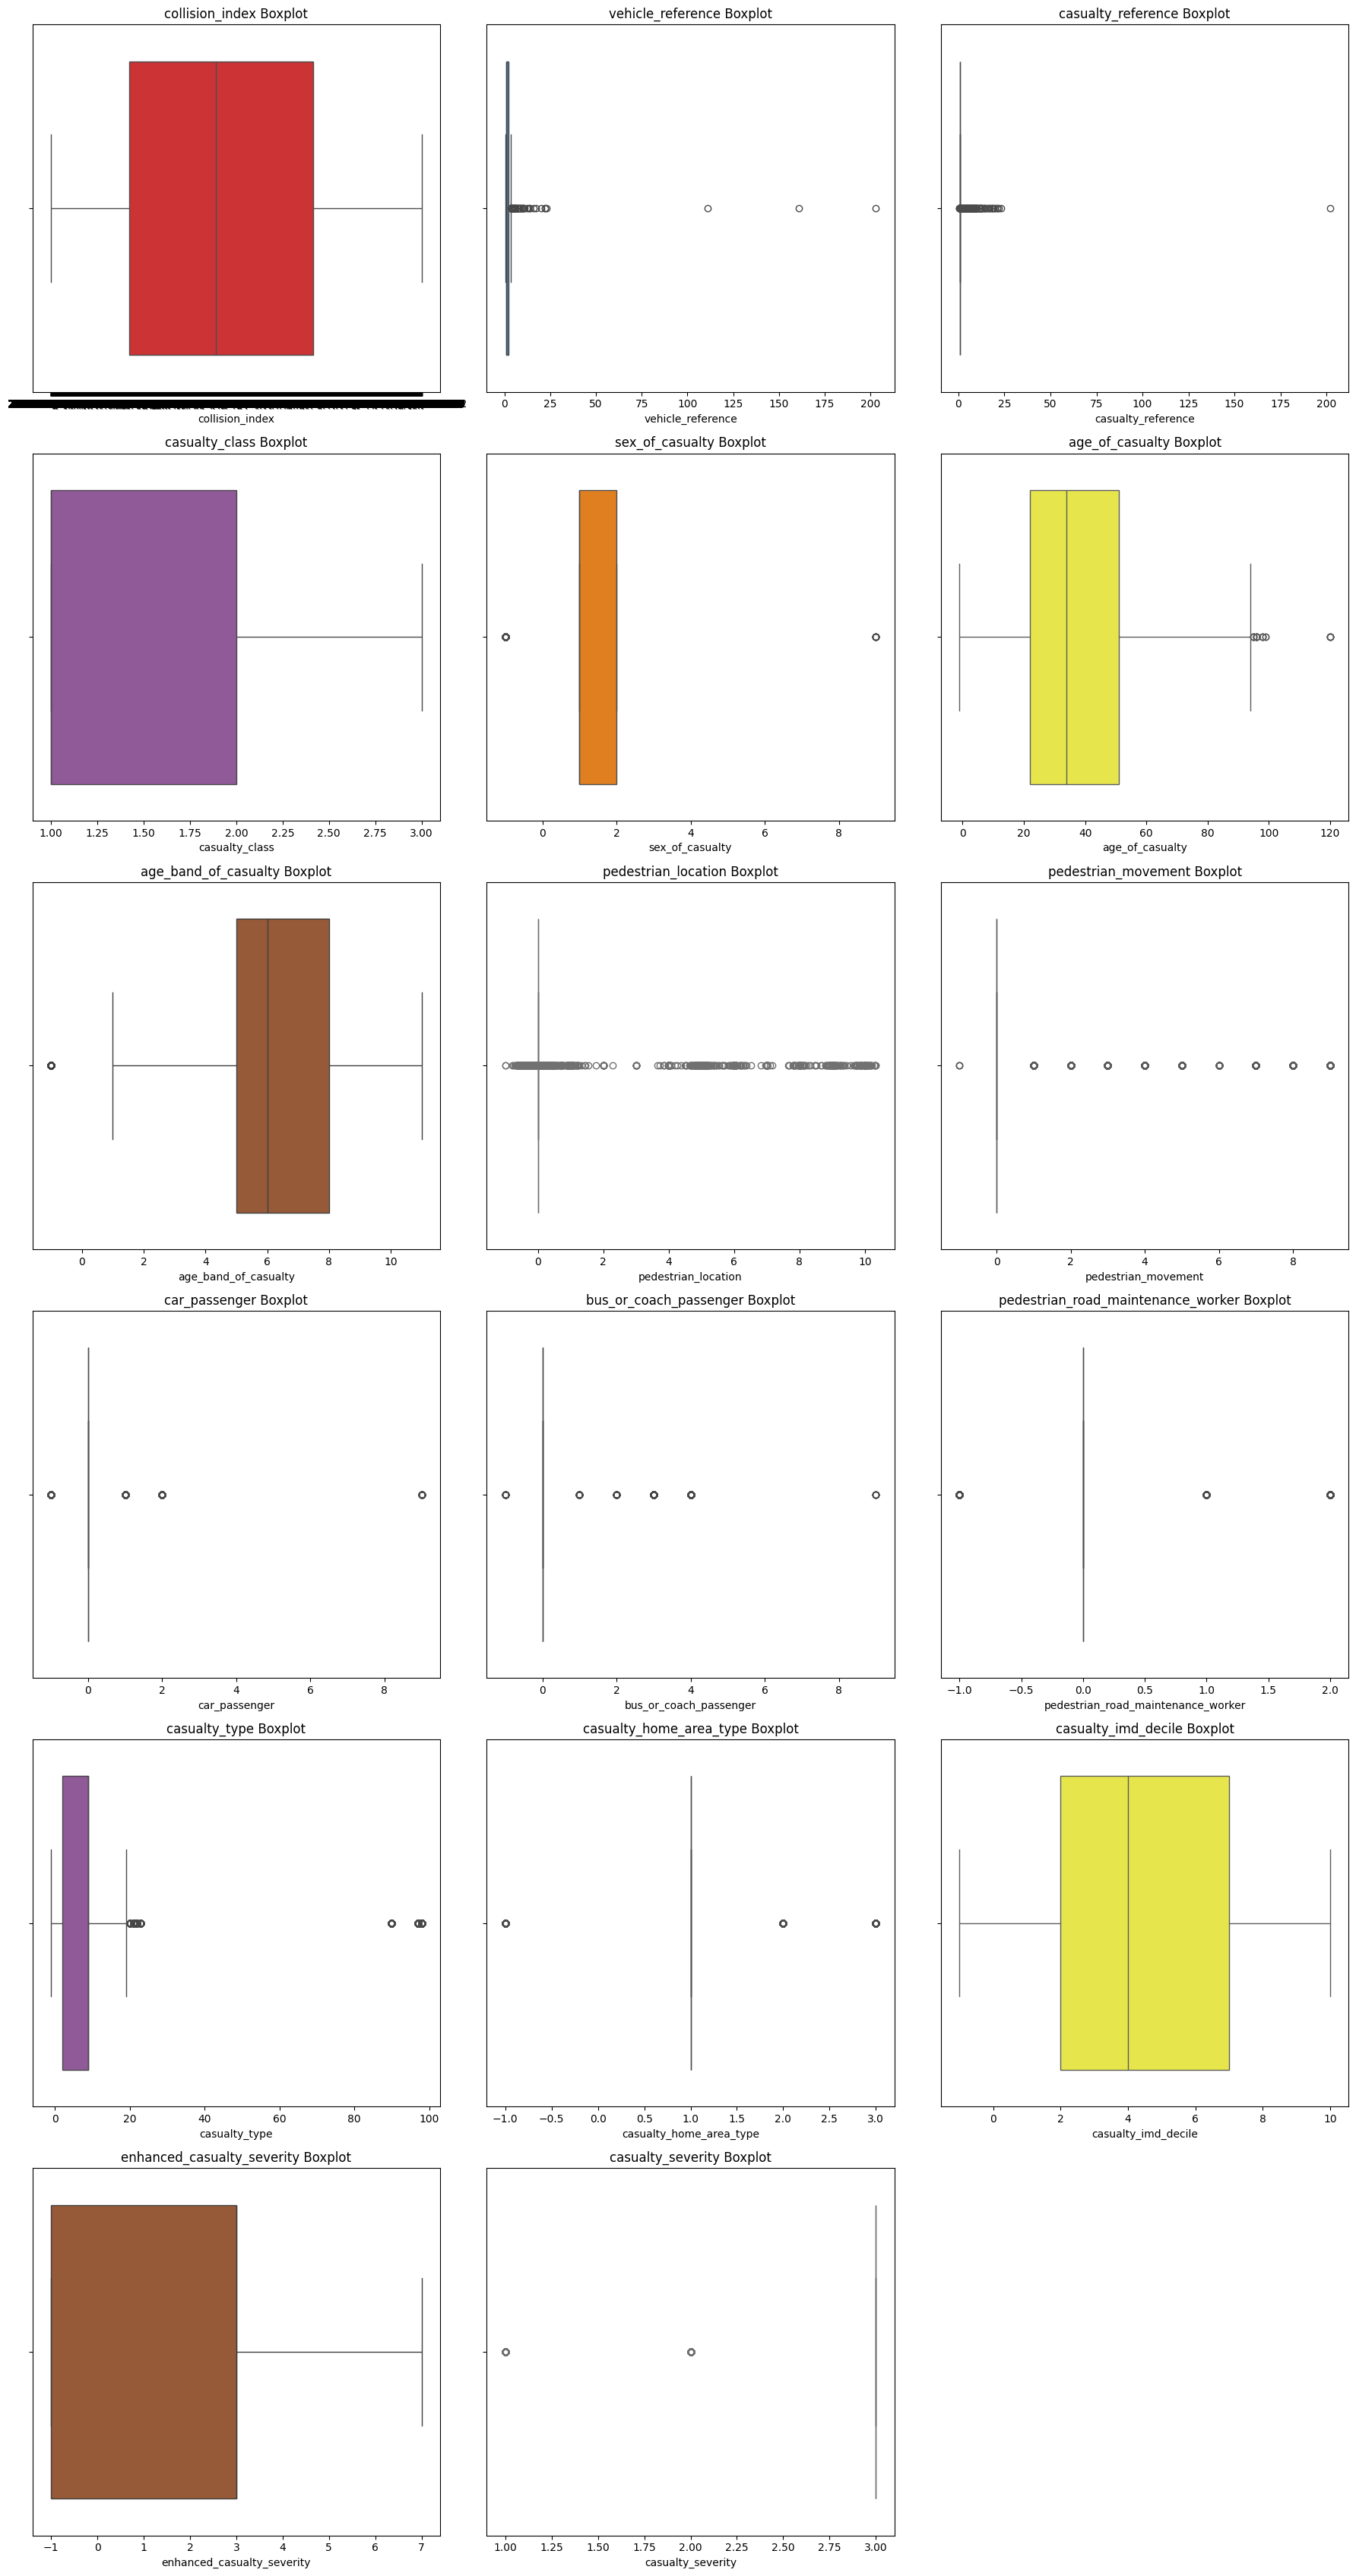

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

col_box = [
    'collision_index', 'vehicle_reference', 'casualty_reference',
    'casualty_class', 'sex_of_casualty', 'age_of_casualty',
    'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement',
    'car_passenger', 'bus_or_coach_passenger',
    'pedestrian_road_maintenance_worker', 'casualty_type',
    'casualty_home_area_type', 'casualty_imd_decile',
    'enhanced_casualty_severity', 'casualty_severity'
]

color_palette = sns.color_palette("Set1", len(col_box))

plt.figure(figsize=(18, len(col_box) * 2))

for i, column in enumerate(col_box, 1):
    plt.subplot((len(col_box) // 3) + 1, 3, i)
    sns.boxplot(data=df, x=column, color=color_palette[i - 1])
    plt.xlabel(column)
    plt.title(f'{column} Boxplot')

plt.tight_layout()
plt.show()


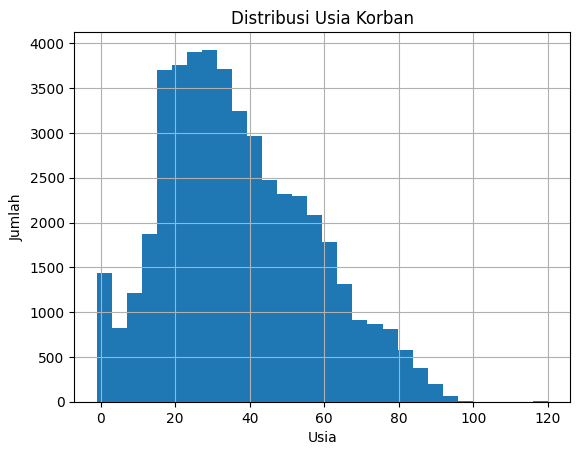

In [5]:
df['age_of_casualty'].hist(bins=30)
plt.title("Distribusi Usia Korban")
plt.xlabel("Usia")
plt.ylabel("Jumlah")
plt.show()


In [6]:
!pip install optuna

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import optuna

# Salin data
train = df.copy()

# Fitur dan target
X = train.drop(['casualty_severity'], axis=1)
y = train['casualty_severity'] - 1
print("Fitur yang digunakan:\n", X.columns.tolist())

# Label encoding untuk kategorikal
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Split data
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=random_state)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Model-model
classifiers = [
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("GaussianNB", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("XGBoost", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ("AdaBoost", AdaBoostClassifier(random_state=random_state)),
    ("GradientBoost", GradientBoostingClassifier(random_state=random_state)),
    ("Bagging", BaggingClassifier(random_state=random_state)),
]

# Tambahkan VotingClassifier (gabungan 3 terbaik)
voting = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(random_state=random_state)),
    ('xgb', XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ('gb', GradientBoostingClassifier(random_state=random_state))
], voting='soft')

classifiers.append(("Voting", voting))

# Cross-validation
cv_results = []
for name, model in classifiers:
    scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=kfold, n_jobs=-1)
    cv_results.append((name, scores.mean(), scores.std()))

# Hasil sebagai DataFrame
cv_res = pd.DataFrame(cv_results, columns=["Algorithm", "CrossValMeans", "CrossValStd"])
cv_res = cv_res.sort_values(by='CrossValMeans', ascending=False)

# Tampilkan hasil
print(cv_res)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 24.4 MB/s eta 0:00:00
Fitur yang digunakan:
 ['collision_index', 'vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile', 'enhanced_casualty_severity']
       Algorithm  CrossValMeans  CrossValStd
8         Voting       0.967979     0.000743
6  GradientBoost       0.967389     0.000701
4        XGBoost       0.966719     0.000898
3  Random Forest       0.966478     0.000840
7        Bagging       0.960583     0.000936
5       AdaBoost       0.956376     0.000952
2  Decision Tree       0.939548     0.001463
0            KNN       0.889065     0.001453
1     GaussianNB       0.847343     0.00488

In [7]:
import optuna
from xgboost import XGBClassifier

def objective_xgb(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'mlogloss'
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30)
print("Best XGBoost params:", study_xgb.best_params)
print("Best XGBoost accuracy:", study_xgb.best_value)

[I 2025-06-10 21:01:48,476] A new study created in memory with name: no-name-023ced8c-c82f-4cc8-91ce-48f2f1fa2373
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:01:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:01:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:01:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:01:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-package

Best XGBoost params: {'max_depth': 7, 'learning_rate': 0.2359782567798041, 'n_estimators': 169, 'subsample': 0.9164284317895103, 'colsample_bytree': 0.9870113967843601, 'gamma': 2.104555451344951, 'reg_alpha': 1.3445284724960733, 'reg_lambda': 0.2139048652770632}
Best XGBoost accuracy: 0.9684075056093089


In [8]:
from sklearn.ensemble import GradientBoostingClassifier

def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }
    model = GradientBoostingClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=30)
print("Best GradientBoost params:", study_gb.best_params)
print("Best GradientBoost accuracy:", study_gb.best_value)


[I 2025-06-10 21:04:38,566] A new study created in memory with name: no-name-23cdaea2-12b3-463e-87db-ab863ee2967f
[I 2025-06-10 21:07:07,069] Trial 0 finished with value: 0.9666925679367984 and parameters: {'n_estimators': 214, 'learning_rate': 0.09699666567732526, 'max_depth': 8, 'subsample': 0.8168381888577786, 'max_features': 'log2'}. Best is trial 0 with value: 0.9666925679367984.
[I 2025-06-10 21:09:37,092] Trial 1 finished with value: 0.9669337254930683 and parameters: {'n_estimators': 241, 'learning_rate': 0.06533899647459566, 'max_depth': 8, 'subsample': 0.7469820403656271, 'max_features': 'log2'}. Best is trial 1 with value: 0.9669337254930683.
[I 2025-06-10 21:10:25,492] Trial 2 finished with value: 0.9659690773159018 and parameters: {'n_estimators': 102, 'learning_rate': 0.1458255352643972, 'max_depth': 7, 'subsample': 0.8052396104623573, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9669337254930683.
[I 2025-06-10 21:14:34,687] Trial 3 finished with value: 0.959082

Best GradientBoost params: {'n_estimators': 127, 'learning_rate': 0.015539414363935633, 'max_depth': 5, 'subsample': 0.6013780101099223, 'max_features': None}
Best GradientBoost accuracy: 0.968327119757219


In [9]:
from sklearn.ensemble import VotingClassifier

def objective_voting(trial):
    voting_type = trial.suggest_categorical("voting", ["hard", "soft"])

    clf1 = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    clf2 = GradientBoostingClassifier(random_state=42)
    clf3 = RandomForestClassifier(random_state=42)

    model = VotingClassifier(estimators=[
        ('xgb', clf1),
        ('gb', clf2),
        ('rf', clf3)
    ], voting=voting_type)

    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

study_vote = optuna.create_study(direction='maximize')
study_vote.optimize(objective_voting, n_trials=10)
print("Best Voting params:", study_vote.best_params)
print("Best Voting accuracy:", study_vote.best_value)


[I 2025-06-10 21:53:23,052] A new study created in memory with name: no-name-3bf1b2fd-c779-4818-8088-5ce0e5dcbb68
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:53:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:53:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:53:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:54:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-package

Best Voting params: {'voting': 'soft'}
Best Voting accuracy: 0.9682199386210989


In [10]:
print("=== Best XGBoost Hyperparameters ===")
print(study_xgb.best_params)
print("Best XGBoost Accuracy:", study_xgb.best_value)

print("\n=== Best GradientBoost Hyperparameters ===")
print(study_gb.best_params)
print("Best GradientBoost Accuracy:", study_gb.best_value)

print("\n=== Best Voting Hyperparameters ===")
print(study_vote.best_params)
print("Best Voting Accuracy:", study_vote.best_value)


=== Best XGBoost Hyperparameters ===
{'max_depth': 7, 'learning_rate': 0.2359782567798041, 'n_estimators': 169, 'subsample': 0.9164284317895103, 'colsample_bytree': 0.9870113967843601, 'gamma': 2.104555451344951, 'reg_alpha': 1.3445284724960733, 'reg_lambda': 0.2139048652770632}
Best XGBoost Accuracy: 0.9684075056093089

=== Best GradientBoost Hyperparameters ===
{'n_estimators': 127, 'learning_rate': 0.015539414363935633, 'max_depth': 5, 'subsample': 0.6013780101099223, 'max_features': None}
Best GradientBoost Accuracy: 0.968327119757219

=== Best Voting Hyperparameters ===
{'voting': 'soft'}
Best Voting Accuracy: 0.9682199386210989


In [12]:
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score

best_xgb = XGBClassifier(
    max_depth=7,
    learning_rate=0.2359782567798041,
    n_estimators=169,
    subsample=0.9164284317895103,
    colsample_bytree=0.9870113967843601,
    gamma=2.104555451344951,
    reg_alpha=1.3445284724960733,
    reg_lambda=0.2139048652770632,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

best_gb = GradientBoostingClassifier(
    n_estimators=127,
    learning_rate=0.015539414363935633,
    max_depth=5,
    subsample=0.6013780101099223,
    max_features=None,
    random_state=42
)

voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('gb', best_gb),
        ('rf', RandomForestClassifier(random_state=42))
    ],
    voting='soft'
)

best_xgb.fit(X_train, y_train)
best_gb.fit(X_train, y_train)
voting_clf.fit(X_train, y_train)

xgb_acc = accuracy_score(y_test, best_xgb.predict(X_test))
gb_acc = accuracy_score(y_test, best_gb.predict(X_test))
voting_acc = accuracy_score(y_test, voting_clf.predict(X_test))

print(f"XGBoost Validation Accuracy: {xgb_acc:.5f}")
print(f"GradientBoost Validation Accuracy: {gb_acc:.5f}")
print(f"VotingClassifier Validation Accuracy: {voting_acc:.5f}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:13:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:13:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Validation Accuracy: 0.96742
GradientBoost Validation Accuracy: 0.96752
VotingClassifier Validation Accuracy: 0.96742
